# Employee Attrition Prediction Using Machine Learning

## Data Loading & Exploration

Step 1: Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Step 2: Load Dataset

In [49]:
df = pd.read_csv("HR_Attrition.csv")

print(df.head(10))

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

Step 3: Dataset Shape

In [50]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


Step 4: Target Column

In [51]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


Step 5: Attrition Rate

In [52]:
attrition_rate = (df["Attrition"].value_counts(normalize=True)["Yes"]*100 )

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


Step 6: Numeric vs Categorical

In [53]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric: 26
Categorical: 9


## Data Cleaning & Preprocessing

Missing Values

In [54]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Remove Unnecessary Columns

In [55]:
drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df.drop(columns=drop_cols, inplace=True)

Convert Target Variable

In [56]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

Separate Features

In [57]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

One-Hot Encoding

In [58]:
X = pd.get_dummies(
    X,
    drop_first=True
)

Train-Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Feature Scaling

In [60]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Exploratory Data Analysis

Attrition by Department

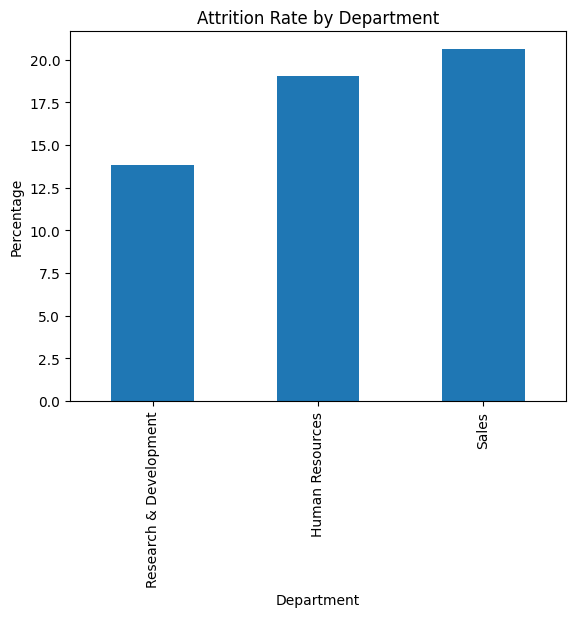

In [61]:
dept_attr = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

dept_attr[1].sort_values().plot(
    kind="bar"
)

plt.title("Attrition Rate by Department")
plt.ylabel("Percentage")
plt.show()

Attrition by Job Role

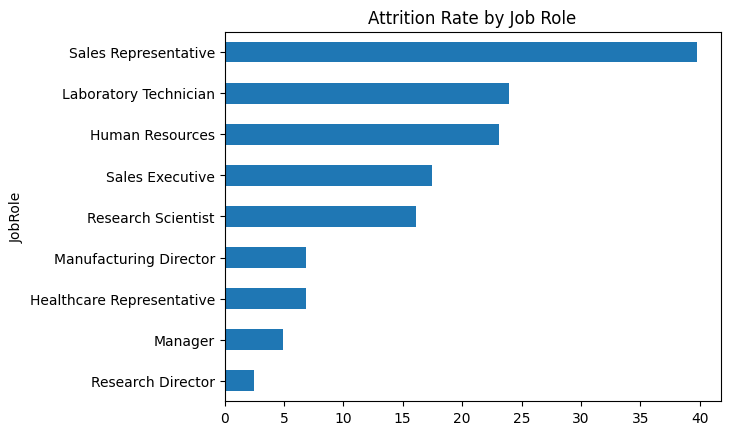

In [62]:
role_attr = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

role_attr[1].sort_values().plot(
    kind="barh"
)

plt.title("Attrition Rate by Job Role")
plt.show()

Monthly Income vs Attrition

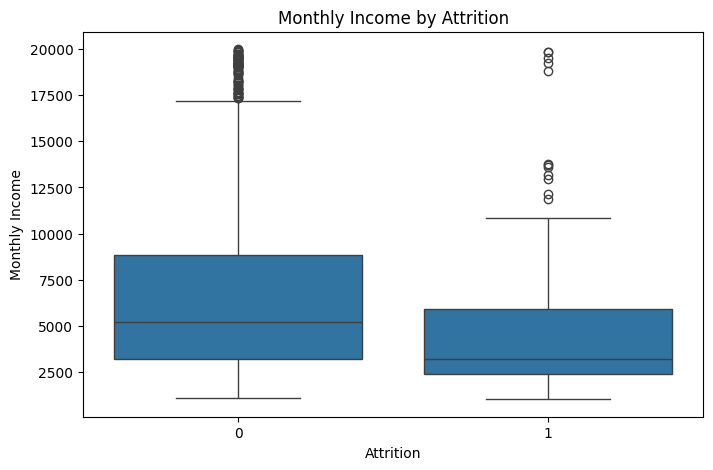

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

Work-Life Balance

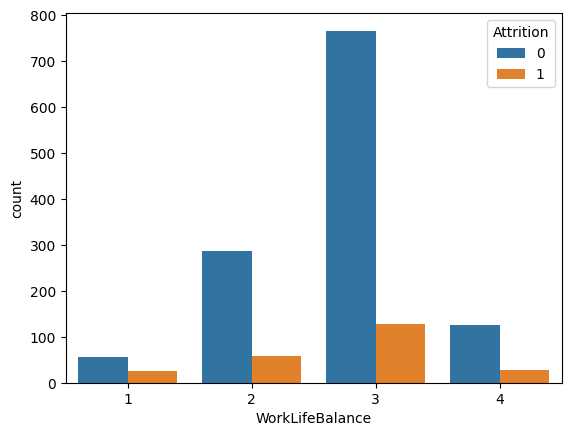

In [64]:
sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)
plt.show()

Years at Company

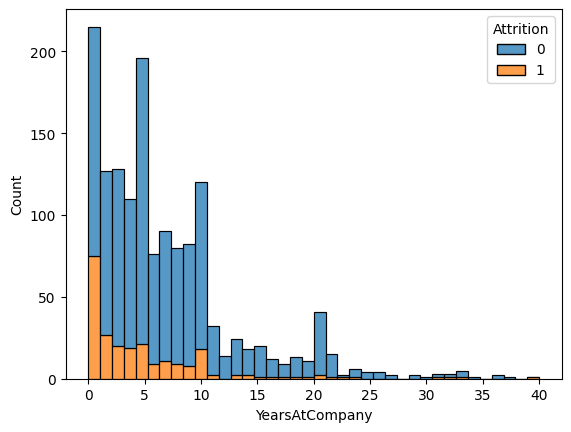

In [65]:
sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)
plt.show()

# Model Building

Import Models

In [66]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

Logistic Regression

In [67]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', random_state=42)

Random Forest

In [68]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Gradient Boosting

In [69]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

## Model Evaluation

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

Create an Evaluation Function

In [71]:
def evaluate_model(model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1-Score :", round(f1,4))
    print("ROC-AUC  :", round(roc_auc,4))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    return {
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1 Score":f1,
        "ROC-AUC":roc_auc
    }

Evaluate All Models

In [72]:
lr_result = evaluate_model(lr, X_test, y_test)

rf_result = evaluate_model(rf, X_test, y_test)

gb_result = evaluate_model(gb, X_test, y_test)

LogisticRegression
Accuracy : 0.7517
Precision: 0.3452
Recall   : 0.617
F1-Score : 0.4427
ROC-AUC  : 0.7983

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

RandomForestClassifier
Accuracy : 0.8435
Precision: 0.5714
Recall   : 0.0851
F1-Score : 0.1481
ROC-AUC  : 0.783

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

GradientBoostingClassifier
Accuracy : 0.8503
Precision: 0.5882
Recall   : 0.21

Create Comparison Table

In [73]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        lr_result["Accuracy"],
        rf_result["Accuracy"],
        gb_result["Accuracy"]
    ],

    "Precision":[
        lr_result["Precision"],
        rf_result["Precision"],
        gb_result["Precision"]
    ],

    "Recall":[
        lr_result["Recall"],
        rf_result["Recall"],
        gb_result["Recall"]
    ],

    "F1 Score":[
        lr_result["F1 Score"],
        rf_result["F1 Score"],
        gb_result["F1 Score"]
    ],

    "ROC-AUC":[
        lr_result["ROC-AUC"],
        rf_result["ROC-AUC"],
        gb_result["ROC-AUC"]
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7517,0.3452,0.6170,0.4427,0.7983
1,Random Forest,0.8435,0.5714,0.0851,0.1481,0.7830
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941


Identify the Best Model

In [74]:
best_model_name = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


Best Model Automatically

In [75]:
if best_model_name == "Gradient Boosting":
    best_model = gb

elif best_model_name == "Random Forest":
    best_model = rf

else:
    best_model = lr

Plot Confusion Matrix for Best Model

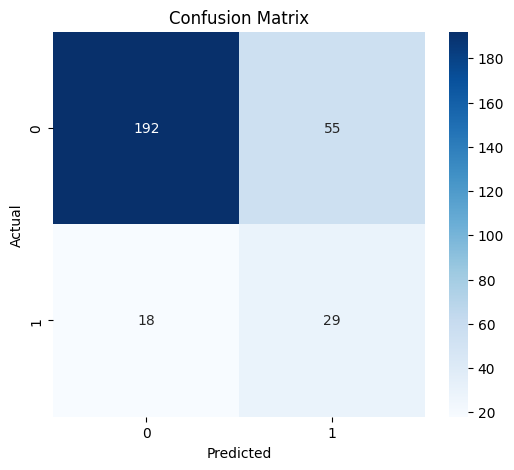

In [76]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Extract Feature Importance

In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(best_model.coef_[0])   # Absolute coefficient values
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


Top 10 Feature Importance Chart

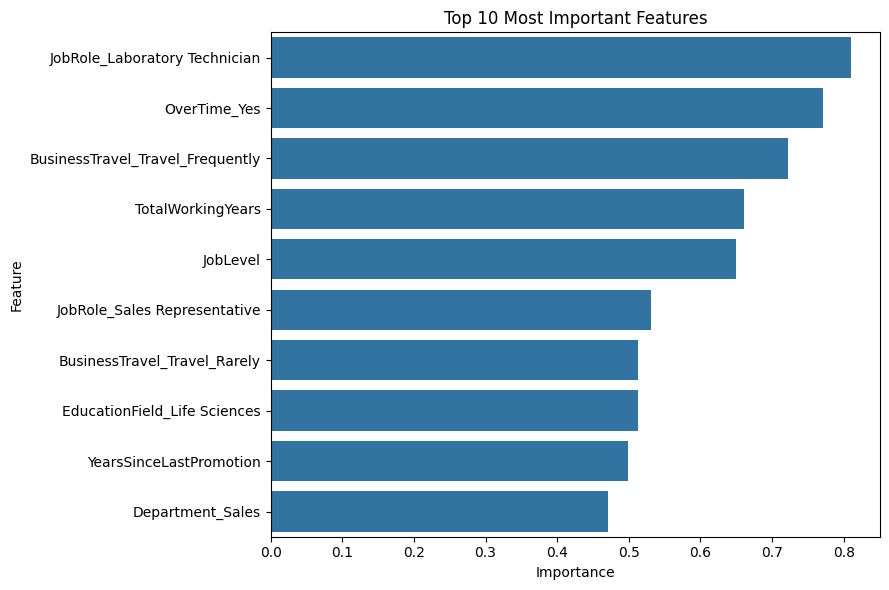

In [78]:
top10 = importance.head(10)

plt.figure(figsize=(9,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.tight_layout()

plt.show()

ROC Curve Comparison

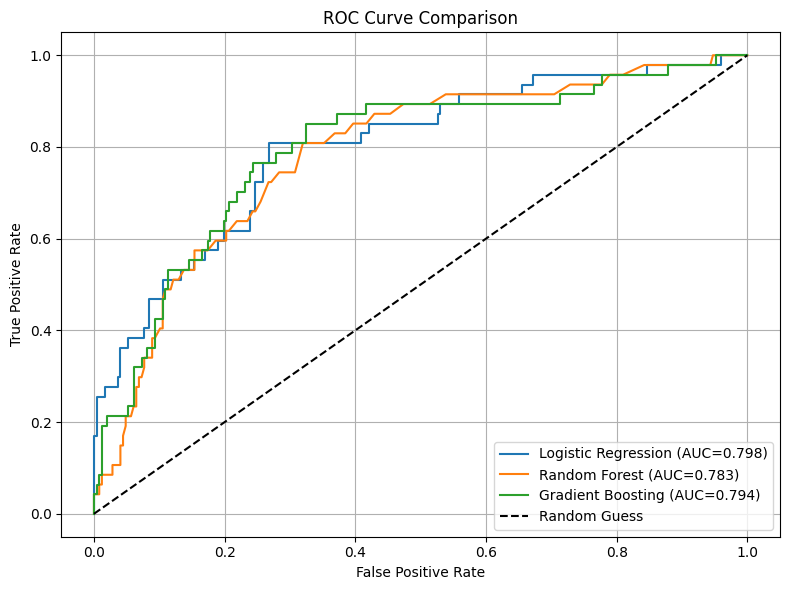

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

# AUC Scores
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
gb_auc = roc_auc_score(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC={lr_auc:.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC={rf_auc:.3f})'
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f'Gradient Boosting (AUC={gb_auc:.3f})'
)

plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

plt.savefig("charts/chart5_roc_curve.png")

plt.show()

# HR Insights & Business Recommendations

Based on the analysis, the three strongest factors influencing employee attrition were OverTime, Job Satisfaction, and Monthly Income. Employees who frequently worked overtime, reported lower job satisfaction, and earned comparatively lower salaries were more likely to leave the company. The Sales department, particularly Sales Representatives (or replace with the highest-attrition role from your EDA), should be prioritized for retention efforts because it showed the highest employee turnover. Salary alone does not fully explain attrition; work-life balance, job satisfaction, and overtime also play significant roles in an employee's decision to leave. To reduce attrition, HR should identify employees who regularly work overtime and provide workload management or flexible work arrangements. Additionally, HR should conduct regular employee satisfaction surveys and career development discussions to address concerns before employees decide to resign. One limitation of this model is that it relies only on historical HR data and cannot capture personal reasons for leaving, such as family responsibilities, better external opportunities, or individual career preferences.